# Plots for ring road graphs

In [1]:
import os
import csv
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from cv2 import norm
import matplotlib.colors as mcolors

def desaturate_cmap(cmap, saturation=0.6):
    colors = cmap(np.linspace(0, 1, cmap.N))
    hsv = mcolors.rgb_to_hsv(colors[:, :3])
    hsv[:, 1] *= saturation  # reduce saturation
    rgb = mcolors.hsv_to_rgb(hsv)
    return mcolors.ListedColormap(rgb)

def cmap_with_alpha_ramp(cmap, alpha_min=0.0, alpha_max=1.0, ramp_fraction=0.3):
    """
    ramp_fraction: fraction of the colormap (from bottom) over which alpha ramps up
    """
    colors = cmap(np.linspace(0, 1, cmap.N))
    alphas = np.ones(cmap.N)

    n_ramp = int(cmap.N * ramp_fraction)
    print('n_ramp:', n_ramp)  
    alphas[:n_ramp] = np.linspace(alpha_min, alpha_max, n_ramp)

    colors[:, -1] = alphas
    return mcolors.ListedColormap(colors)


''' READ BETWEENNESS FILES FROM DIFFERENT GRAPHS AND THE NODE POSITIONS TO PLOT HEXBIN '''
# FOR TWICE RING VELOCITY
# direct_bwss = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx2/'
# pos_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx2/node_pos/'

# FOR SAME VELOCITY AS REST OF THE GRAPH
direct_bwss = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx1/'
pos_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx1/node_pos/'

x_pos = []
y_pos = []
count = 0

#tol_ls = [0, 10, 20, 30]
tol_ls = [0, 10, 20]

tot_tol_bw =[]
for l in tol_ls:
    tot_tol_bw.append([])

for bw_folder in os.listdir(direct_bwss):
    if bw_folder.startswith('bwss'):
        ind = bw_folder[5:]
        pos_i_dir = pos_dir + 'pos_ring' + ind + '.csv'
        count += 1
        # read the node positions
        with open(pos_i_dir, 'r') as csvfile:
            csvreader = csv.reader(csvfile, delimiter=',')
            csvreader.__next__()  # Skip header row
            for n_i, row in enumerate(csvreader):
                if row[0].isdigit(): 
                    x_pos.append(float(row[1]))
                    y_pos.append(float(row[2]))

        nnodes = n_i + 1  # total number of nodes

        for bw_file in os.listdir(direct_bwss+ bw_folder):
            if 'qsp' not in bw_file:
                continue
            print('Reading file:', bw_file)
            tol = ''
            for i in bw_file:
                if i.isdigit():
                    tol += i
            tol = int(tol)
            ind = tol_ls.index(tol)
            
            with open(direct_bwss+bw_folder+'/'+bw_file, 'r') as csvfile:
                csvreader = csv.reader(csvfile, delimiter=',')
                csvreader.__next__()  # Skip header row
                for row in csvreader:
                    tot_tol_bw[ind].append(float(row[1])*2/((nnodes-1)*(nnodes-2)))            



Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw_tol_20.csv
Reading file: qspbw_tol_10.csv
Reading file: qspbw_tol_0.csv
Reading file: qspbw

n_ramp: 128
max value: 0.2821691729323308


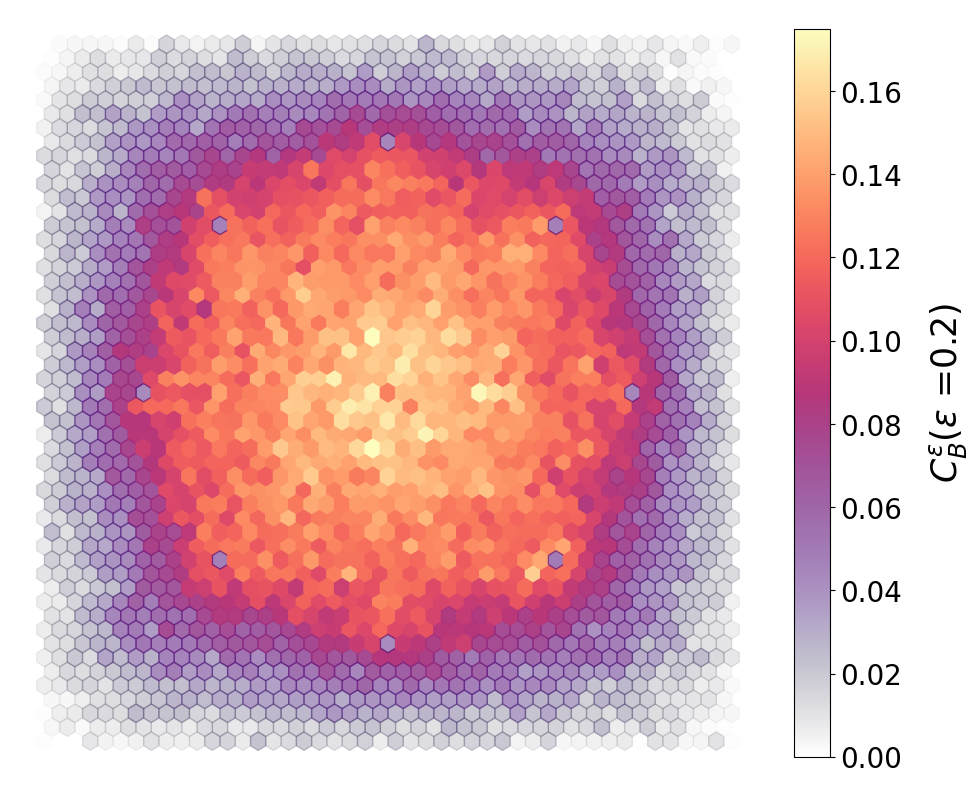

In [3]:
tol_i = 2

# Plot Hexbin
gridsize = 45
mincnt = 1
# Define a custom colormap with reversed order
cmap = plt.colormaps['magma']
cmap = cmap_with_alpha_ramp(cmap, alpha_min=0, alpha_max=1.0, ramp_fraction=0.5)
norm = colors.Normalize(vmin=0, vmax=0.175)

# Create a hexbin plot of the data
fig, ax = plt.subplots(figsize=(10, 8))

hb = ax.hexbin(x_pos, y_pos, C=np.array(tot_tol_bw[tol_i]), gridsize=gridsize, cmap=cmap, mincnt=mincnt, norm=norm)
print('max value:', np.max(np.array(tot_tol_bw[tol_i])))
offs = hb.get_offsets()

hxvals_arr = hb.get_array()

# max_ind = np.argmax(hxvals_arr)
# max_val = np.max(hxvals_arr)

# circle=plt.Circle(offs[max_ind], 0.09, color = "#0A429C", fill=False, linewidth=4,
#                   label = 'max. val. = '+str(round(max_val, 3)))
# ax.add_patch(circle)

#Ring nodes

# for i, pos_x, pos_y in zip(range(8),x_pos[:8], y_pos[:8]):
#     if  i == 0:
#         circle=plt.Circle((pos_x, pos_y), 0.05, color = "#000000", fill=False, 
#                           label = 'ring nodes', linewidth=5)
#     else:
#         circle=plt.Circle((pos_x, pos_y), 0.05, color = "#000000", fill=False, linewidth=5)

#     ax.add_patch(circle)


# Show the legend on the right side
plt.subplots_adjust(bottom=0.2)

# ax_legend = plt.axes([0., 0.05, 0.5, 0.05])
cbar = plt.colorbar(hb, orientation='vertical', shrink = 0.95, pad=0.03)
cbar.set_label(r'$C_B^{\varepsilon}$'+fr'($\varepsilon$ ={tol_ls[tol_i]/100})', fontsize=25, labelpad=18)

cbar.ax.tick_params(labelsize=20)

ax.axis('off')
#plt.legend(fontsize = 16)
# Show the plot
plt.tight_layout()
# plt.savefig('./figs/hexbin_bwss_ring_roads_vx1_tol20_ring_nodes.png', dpi=300)
plt.show()

max value: 0.3496854636591478


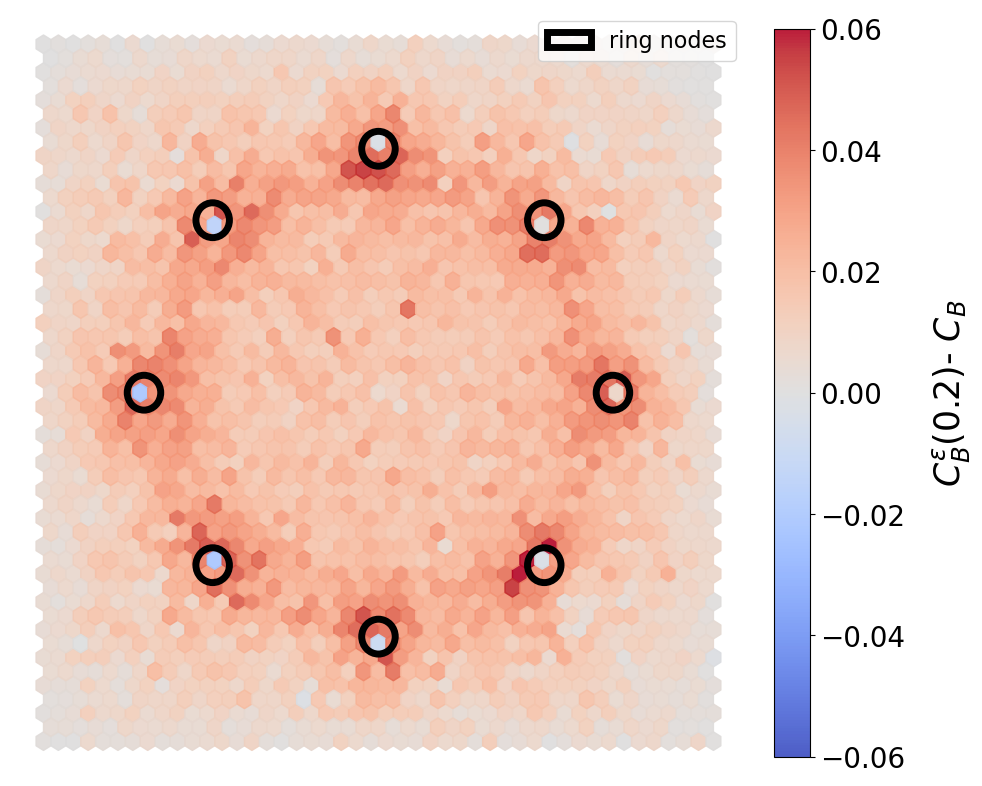

In [216]:
tol_i = 2

# Plot Hexbin
gridsize = 45
mincnt = 1
# Define a custom colormap with reversed order
# cmap = plt.colormaps['magma']
# cmap = cmap_with_alpha_ramp(cmap, alpha_min=0, alpha_max=1.0, ramp_fraction=0.5)
# norm = colors.Normalize(vmin=0, vmax=0.175)

cmap = plt.colormaps['coolwarm']
norm = colors.Normalize(vmin=-0.06, vmax=0.06)

#tot_diff_bw
#tot_tol_bw
# Create a hexbin plot of the data
fig, ax = plt.subplots(figsize=(10, 8))

# hb = ax.hexbin(x_pos, y_pos, C=np.array(tot_tol_bw[2]), gridsize=gridsize, cmap=cmap, mincnt=mincnt, norm=norm)
hb = ax.hexbin(x_pos, y_pos, C=np.array(tot_tol_bw[2])-np.array(tot_tol_bw[0]), gridsize=gridsize, cmap=cmap, norm=norm, mincnt=mincnt, alpha=0.9)#
print('max value:', np.max(np.array(tot_tol_bw[2])))
offs = hb.get_offsets()
# 0.375
# 0.363
# 0.350

hxvals_arr = hb.get_array()

# max_ind = np.argmax(hxvals_arr)
# max_val = np.max(hxvals_arr)

# circle=plt.Circle(offs[max_ind], 0.09, color = "#0A429C", fill=False, linewidth=4,
#                   label = 'max. val. = '+str(round(max_val, 3)))
# ax.add_patch(circle)

#Ring nodes

for i, pos_x, pos_y in zip(range(8),x_pos[:8], y_pos[:8]):
    if  i == 0:
        circle=plt.Circle((pos_x, pos_y), 0.05, color = "#000000", fill=False, 
                          label = 'ring nodes', linewidth=5)
    else:
        circle=plt.Circle((pos_x, pos_y), 0.05, color = "#000000", fill=False, linewidth=5)

    ax.add_patch(circle)


# Show the legend on the right side
plt.subplots_adjust(bottom=0.2)

# ax_legend = plt.axes([0., 0.05, 0.5, 0.05])
cbar = plt.colorbar(hb, orientation='vertical', shrink = 0.95, pad=0.03)
# cbar.set_label(r'$C_B^{\varepsilon}$'+f'({tol_ls[tol_i]/100})', fontsize=25, labelpad=18)
cbar.set_label(r'$C_B^{\varepsilon}$'+f'({tol_ls[tol_i]/100})'+ r'- $C_B$', fontsize=25, labelpad=18)

cbar.ax.tick_params(labelsize=20)

ax.axis('off')
plt.legend(fontsize = 16)
# Show the plot
plt.tight_layout()
# plt.savefig('./figs/hexbin_bwss_ring_roads_vx1_tol20_ring_nodes.png', dpi=300)
plt.savefig('./figs/diff_ring_vx2.png', dpi=300)
plt.show()

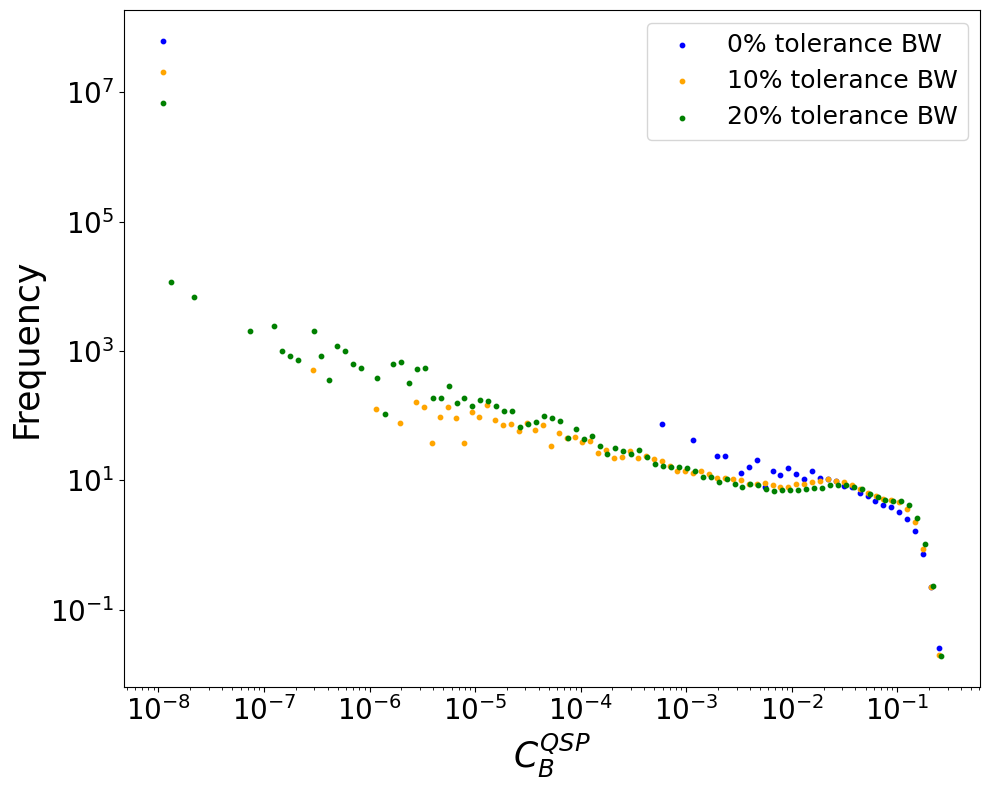

In [3]:
# plot histogram of betweenness values

plt.figure(figsize=(10, 8))
cols = ['blue', 'orange', 'green', 'red']
# cmap1 = plt.colormaps['Blues']
# cmap2 = plt.colormaps['Oranges']
# cmap3 = plt.colormaps['Greens']
# cmap4 = plt.colormaps['Reds']
# cmap_ls = [cmap1, cmap2, cmap3, cmap4]
# r_pos_hb = np.array([np.linalg.norm(np.array([x, y])) for x, y in hb.get_offsets()])

for i in range(len(tol_ls)):

    # data, bins = np.histogram(tot_tol_bw[i], bins=100)
    tol_i = np.array(tot_tol_bw[i])
    tol_i[tol_i == 0] = 10e-9 # Replace zeros with a small value to avoid log(0)
    # Step 1: Define log-spaced bins
    bins = np.logspace(np.log10(min(tol_i[tol_i>0])), max(np.log10(tol_i)), num=100)
    # Step 2: Compute histogram
    counts, edges = np.histogram(tol_i, bins=bins, density=True)

    # Step 3: Get bin centers
    centers = (edges[:-1] + edges[1:]) / 2
    # plot of distribution in loglog

    # bins_new = bins[:-1] + (bins[1]-bins[0])/2  # Adjust bins to center the ticks
    plt.scatter(centers, counts, s=10, alpha=1, color = cols[i], label=f'{tol_ls[i]}% tolerance BW')
plt.semilogx()
plt.semilogy()
plt.ylabel('Frequency', fontsize = 25)
plt.xlabel(r'$C_B^{QSP}$', fontsize = 25)
plt.legend(fontsize = 18)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.tight_layout()
plt.show()


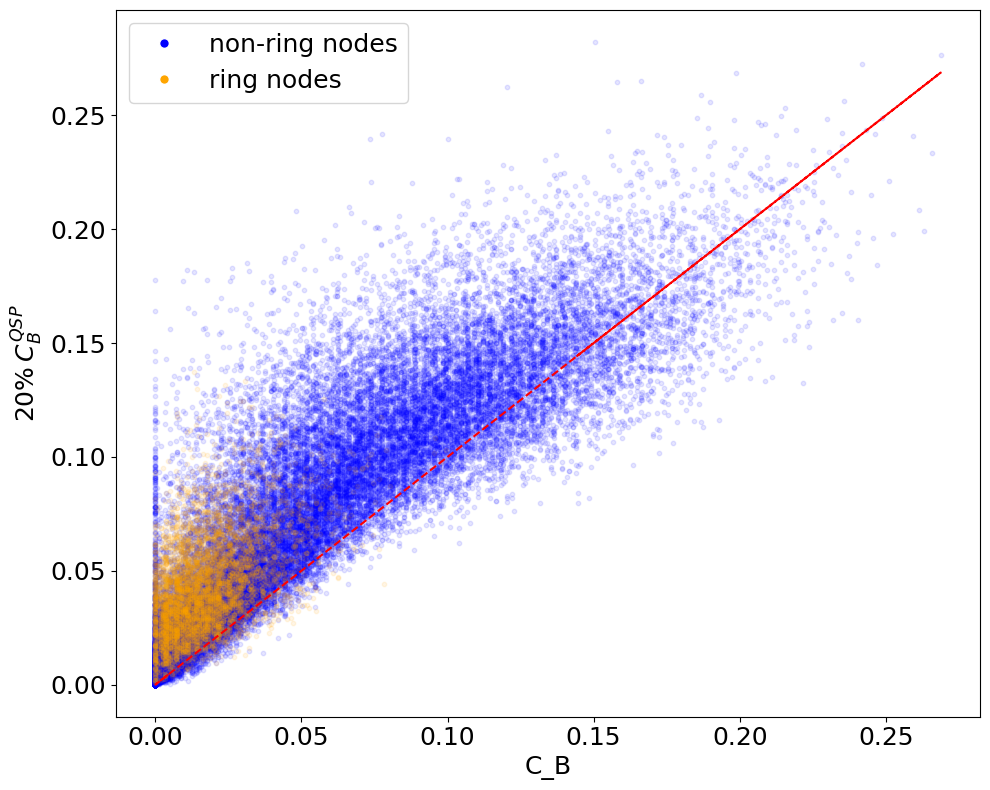

In [4]:
#% plot correlation
plt.figure(figsize=(10, 8))
plt.xlabel(r'C_B', fontsize = 18)
plt.ylabel(r'$20\% \: C_B^{QSP}$', fontsize = 18)


ring_bw_0 = []
ring_bw_tol = []

rest_0 = []
rest_tol = []

plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
tol_y = tot_tol_bw[2]
for i in range(count):
    start = nnodes*i
    
    ring_bw_0 += tot_tol_bw[0][start:start+8]
    ring_bw_tol += tol_y[start:start+8]
    
    if i != count-1:
        rest_0 += tot_tol_bw[0][start+8: nnodes*(i+1)]
        rest_tol += tol_y[start+8: nnodes*(i+1)]
    else:
        rest_0 += tot_tol_bw[0][start+8 :]
        rest_tol += tol_y[start+8 :]
    

pear_ring = pearsonr(ring_bw_0, ring_bw_tol)
pear_rest = pearsonr(rest_0, rest_tol)
pear_tot = pearsonr(ring_bw_0+rest_0, ring_bw_tol+rest_tol)



plt.scatter(rest_0, rest_tol, s = 10, alpha = 0.1, c = 'b', 
            label = 'non-ring nodes')
plt.scatter(ring_bw_0, ring_bw_tol, s = 10, alpha = 0.1, c = 'orange', 
            label = 'ring nodes')

    
plt.plot(tot_tol_bw[0], tot_tol_bw[0], c = 'r', linestyle = '--', label = 'y = x')

# Custom legend handles
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='non-ring nodes',
           markerfacecolor='blue', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='ring nodes',
           markerfacecolor='orange', markersize=7)
]

# Add legend to the plot
plt.legend(handles=legend_elements, loc='upper left', fontsize = 18)
plt.tight_layout()
plt.show()

/var/folders/7z/xy3tglwx2_dgnz41stkj54pc0000gn/T/ipykernel_24316/1465689615.py:41: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(np.sqrt(off_ls[i][:, 0]**2+off_ls[i][:, 1]**2), vals_ls[i], s = 60,
/var/folders/7z/xy3tglwx2_dgnz41stkj54pc0000gn/T/ipykernel_24316/1465689615.py:51: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


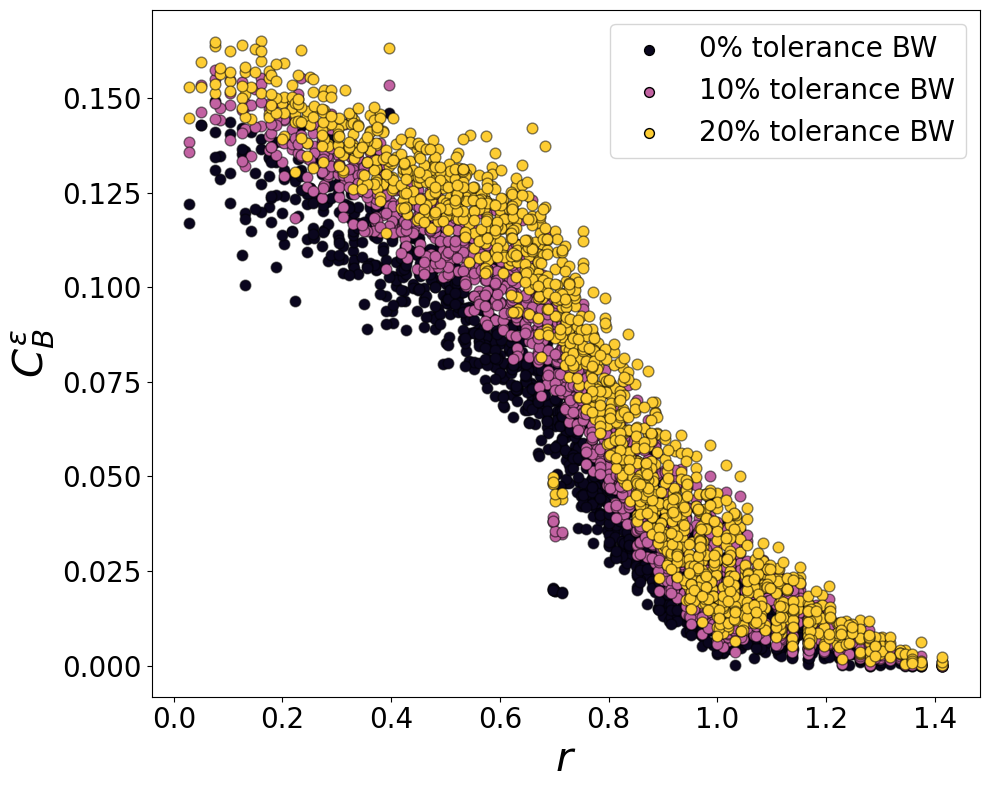

In [125]:
# r_pos = np.array([np.linalg.norm(np.array([x, y])) for x, y in zip(x_pos, y_pos)])

# plt.figure(figsize=(10, 8))
# plt.xlabel(r'$r$', fontsize = 18)
# plt.ylabel(r'$C_B^{QSP}$', fontsize = 18)
# plt.scatter(r_pos, tot_tol_bw[0], s = 10, alpha = 0.1, c = 'blue', label = '0% tolerance BW')
# plt.scatter(r_pos, tot_tol_bw[1], s = 10, alpha = 0.1, c = 'orange', label = '10% tolerance BW')
# plt.scatter(r_pos, tot_tol_bw[2], s = 10, alpha = 0.1, c = 'green', label = '20% tolerance BW')
# plt.xticks(fontsize = 18)
# plt.yticks(fontsize = 18)
# plt.legend(fontsize = 18)
# plt.tight_layout()
# plt.show()

cmap = plt.get_cmap("inferno")

# Generate N evenly spaced colors from the colormap
colors_tol = cmap(np.linspace(0, 0.8, len(tol_ls)))  # Adjust 5 to however many lines you have

colors_tol[:, :3] = colors_tol[:, :3]** 0.5

off_ls = []
vals_ls = []
for i in range(len(tol_ls)):    
    fig, ax = plt.subplots()
    hb = ax.hexbin(
        x_pos, y_pos,
        C=np.array(tot_tol_bw[i]),
        gridsize=gridsize,
        norm=norm,
        mincnt=mincnt
    )
    plt.close(fig)
    off_ls.append(hb.get_offsets())
    vals_ls.append(hb.get_array())

plt.figure(figsize=(10, 8))
plt.xlabel(r'$r$', fontsize = 30)
plt.ylabel(r'$C_B^{\varepsilon}$', fontsize = 30)
for i in range(len(tol_ls)):    
    plt.scatter(np.sqrt(off_ls[i][:, 0]**2+off_ls[i][:, 1]**2), vals_ls[i], s = 60,
                c = colors_tol[i], edgecolors=[0,0,0,0.5],
                label = f'{tol_ls[i]}% tolerance BW')

plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
# Create legend
leg = plt.legend(fontsize = 20)

# Set alpha=1 for the legend markers
for lh in leg.legendHandles:
    lh.set_alpha(1)
    lh.set_sizes([50])  # Increase marker size for better visibility

plt.tight_layout()
plt.savefig('./figs/bw_vs_r_ring_roads_vx1.png')
plt.show()

# Plots for The rest (star and lattice)

In [203]:
import scipy.io as sio
import numpy as np

bw_path = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/MCM/computed_bwss/accumulated_data_lat.mat'
# bw_path = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/MCM/computed_bwss/accumulated_data_star.mat'

bwmat = sio.loadmat(bw_path)
accum_bw2 = bwmat['accum_bw2']
accum_x = bwmat['accum_x'].flatten()
accum_y = bwmat['accum_y'].flatten()

qsp_bw = []
print(accum_bw2.shape, accum_x.shape, accum_y.shape)
for i in range(accum_bw2.shape[1]):    
    # 1) Select the tolerance slice: (graphs, nodes)
    bw = accum_bw2[:, i, :]   # shape: (G, N)

    # 2) Optionally keep only graphs that have at least one nonzero node
    # keep_graph = np.any(bw != 0, axis=1)        # shape: (G,)
    # bw = bw[keep_graph, :]

    # 3) Node-level mask (aligns bw, x, y correctly)
    mask = np.isfinite(bw)  # shape: (G_kept, N)
    
    # 4) Flatten consistently (only where mask is True)
    accum_bw_noz = bw[mask].reshape(1, -1)[0]
    x_nnz = accum_x[mask.flatten()].reshape(1, -1)[0]
    y_nnz = accum_y[mask.flatten()].reshape(1, -1)[0]

    qsp_bw.append(accum_bw_noz)

(100, 3, 100) (10000,) (10000,)


n_ramp: 128
[1144.05        959.9        1187.83       ... 1428.57142857 1428.57142857
 1428.57142857] [ 989.61       1453.75        240.27       ... 1142.85714286 1714.28571429
 2000.        ]


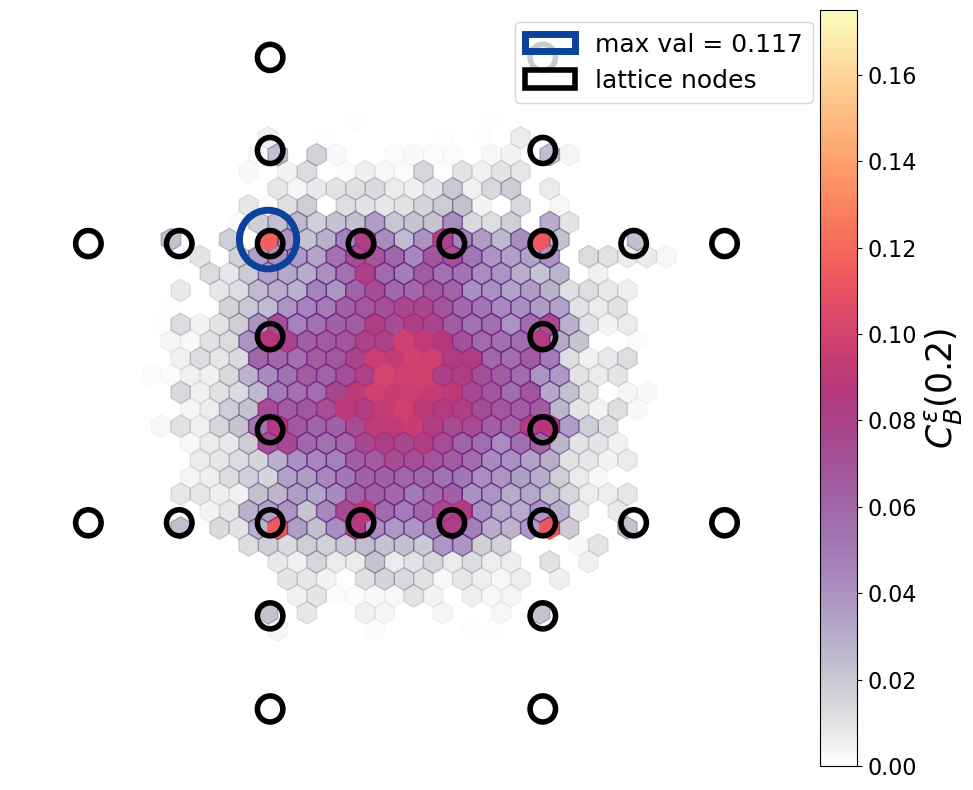

In [205]:
tol_i = 2  # 20% tolerance
fig, ax = plt.subplots(figsize=(10, 8))

# cmap = plt.colormaps['coolwarm']
# norm = colors.Normalize(vmin=-0.06, vmax=0.06)

cmap = plt.colormaps['magma']
cmap = cmap_with_alpha_ramp(cmap, alpha_min=0, alpha_max=1.0, ramp_fraction=0.5)
norm = colors.Normalize(vmin=0, vmax=0.175)

gridsize = 35
hb = ax.hexbin(x_nnz, y_nnz, C=np.array(qsp_bw[tol_i]), gridsize=gridsize, cmap=cmap, mincnt=mincnt, norm=norm)#norm=norm
# hb = ax.hexbin(x_nnz, y_nnz, C=np.array(qsp_bw[tol_i])-np.array(qsp_bw[0]), gridsize=gridsize, cmap=cmap, mincnt=mincnt, norm=norm)#norm=norm

offs = hb.get_offsets()

hxvals_arr = hb.get_array()

max_ind = np.argmax(hxvals_arr)

max_val = np.max(hxvals_arr)

circle=plt.Circle(offs[max_ind], 90, color = '#0A429C', fill=False, linewidth=5,
                  label = 'max val = '+str(round(max_val, 3)))

# circle=plt.Circle(offs[max_ind], 0.07, color = '#0A429C', fill=False, linewidth=5,
#                   label = 'max val = '+str(round(max_val, 3)))

ax.add_patch(circle)

# Show the legend on the right side
plt.subplots_adjust(bottom=0.2)
# ax_legend = plt.axes([0., 0.05, 0.5, 0.05])
cbar = plt.colorbar(hb, orientation='vertical')
# cbar.set_label(r'$C_B^{\varepsilon}(0.2)- C_B$', fontsize = 25)
cbar.set_label(r'$C_B^{\varepsilon}$'+f'({tol_ls[tol_i]/100})', fontsize = 25)
cbar.ax.tick_params(labelsize=16)

for i in range(1, 29):
    pos_x = accum_x[-i]
    pos_y = accum_y[-i]
    if  i == 1:
        circle=plt.Circle((pos_x, pos_y), 40, color = '#000000', fill=False, 
                          label = 'lattice nodes', linewidth=4)
    else:
        circle=plt.Circle((pos_x, pos_y), 40, color = '#000000', fill=False, linewidth=4)

    ax.add_patch(circle)

ax.axis('off')
# Show the plot
plt.legend(fontsize = 18, loc = 'upper right', bbox_to_anchor=(1.07, 1))
plt.tight_layout()
# plt.savefig('./figs/star_bwss_diff_20_0.pdf')
# plt.savefig('./figs/hexbin_bwss_star_tol20.png', dpi=300)

# plt.savefig('./figs/lattice_bwss_diff_20_0.pdf')
plt.savefig('./figs/hexbin_bwss_lattice_tol20.png', dpi=300)

print(accum_x, accum_y)
plt.show()